In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [2]:
from pyhgf.model import Network
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
from jax import config
from models import (
    bayesian_psychophysics,
    cardiac_believing,
    weighted_update,
    sample_cardiac_hgf,
)
import pymc as pm

config.update("jax_enable_x64", True)

plt.rcParams["figure.constrained_layout.use"] = True

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
participant_id = "sub-0038"
session = 1

In [4]:
# load and filter the data -------------------------------------------------------------
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)

In [5]:
if session == 1:
    hrd_df = hrd_df[
        (
            (hrd_df.cohort == "vmp1")
            & (hrd_df.task == "hrd-session1")
            & (hrd_df.participant_id == participant_id)
            & (~hrd_df.Decision.isnull())
        )
    ]
elif session == 2:
    hrd_df = hrd_df[
        (
            ((hrd_df.cohort == "vmp1") & (hrd_df.task == "hrd-session2"))
            | ((hrd_df.cohort == "vmp2") & (hrd_df.task == "hrd-session1"))
        )
        & (hrd_df.participant_id == participant_id)
        & (~hrd_df.Decision.isnull())
    ]

In [6]:
assert len(hrd_df) > 20

In [7]:
# extract variables of interest ------------------------------------------------------
heart_rate = hrd_df[hrd_df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = hrd_df[hrd_df.Modality == "Intero"].responseBPM.to_numpy()
intero_decision = (
    hrd_df[hrd_df.Modality == "Intero"].Decision.to_numpy() == "More"
).astype(int)

extero_tone_1 = hrd_df[hrd_df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = hrd_df[hrd_df.Modality == "Extero"].responseBPM.to_numpy()
extero_decision = (
    hrd_df[hrd_df.Modality == "Extero"].Decision.to_numpy() == "More"
).astype(int)
n = hrd_df.participant_id.nunique()

In [8]:
participant_codes_intero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Intero"].participant_id
).codes

participant_codes_extero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Extero"].participant_id
).codes

In [9]:
input_data_extero = np.array([extero_tone_1, extero_tone_2]).T
input_data_intero = np.array([heart_rate, intero_tone_2]).T

# Standard psychophysics

In [10]:
idata_bayesian_psychophysics, model_bayesian_psychophysics = bayesian_psychophysics(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.90,3
,2000,0,0.90,1
,2000,0,0.87,7
,2000,0,0.87,3


In [11]:
pm.compute_log_likelihood(
    idata_bayesian_psychophysics,
    model=model_bayesian_psychophysics,
    var_names=["bin_intero"],
)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

Warmup iterations saved (warmup_*).

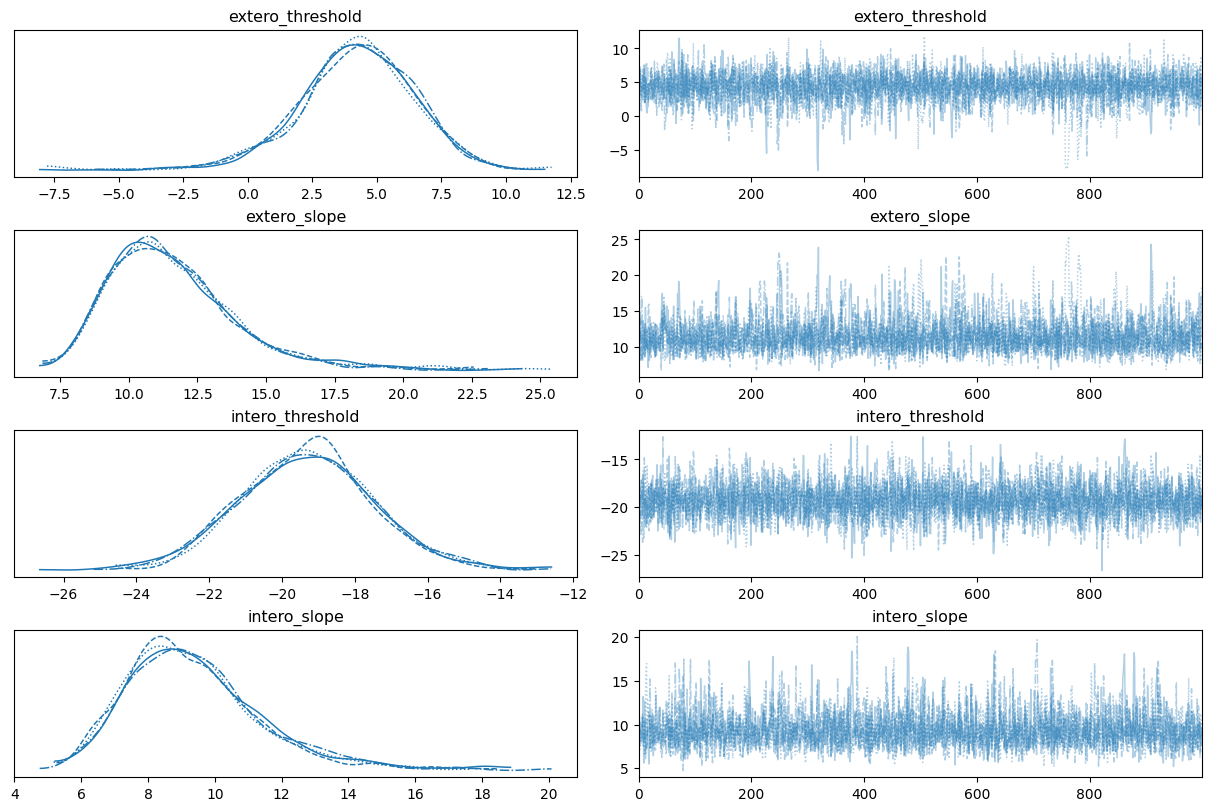

In [12]:
az.plot_trace(
    idata_bayesian_psychophysics,
    var_names=["extero_threshold", "extero_slope", "intero_threshold", "intero_slope"],
);

# Cardiac believing

In [13]:
idata_cardiac_believing, model_cardiac_believing = cardiac_believing(
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.89,3
,2000,0,0.89,3
,2000,0,0.89,3
,2000,0,0.88,7


In [14]:
pm.compute_log_likelihood(
    idata_cardiac_believing, model=model_cardiac_believing, var_names=["bin_intero"]
)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

Warmup iterations saved (warmup_*).

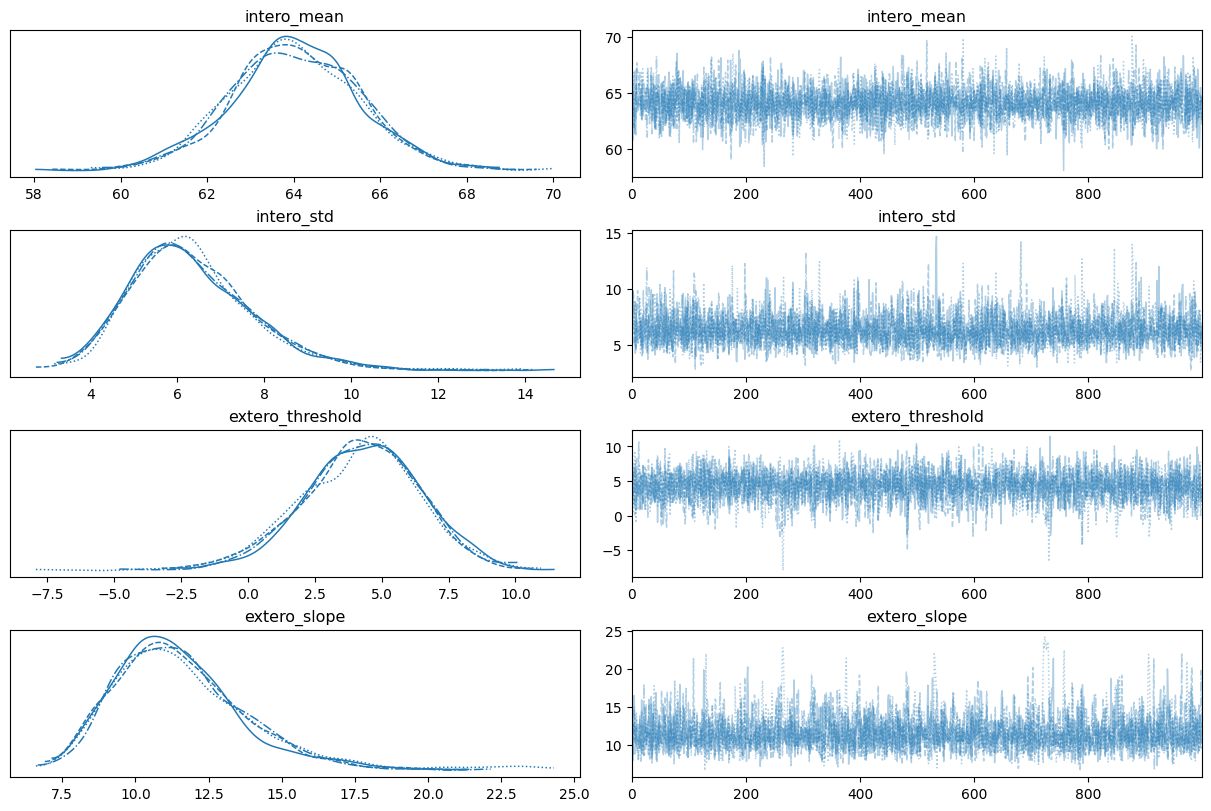

In [15]:
az.plot_trace(
    idata_cardiac_believing,
    var_names=[
        "intero_mean",
        "intero_std",
        "extero_threshold",
        "extero_slope",
    ],
);

# Weighted update

In [20]:
idata_weighted_update, model_weighted_update = weighted_update(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.29,31
,2000,0,0.30,31
,2000,0,0.28,3
,2000,0,0.28,15


In [21]:
pm.compute_log_likelihood(
    idata_weighted_update, model=model_weighted_update, var_names=["bin_intero"]
)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

Warmup iterations saved (warmup_*).

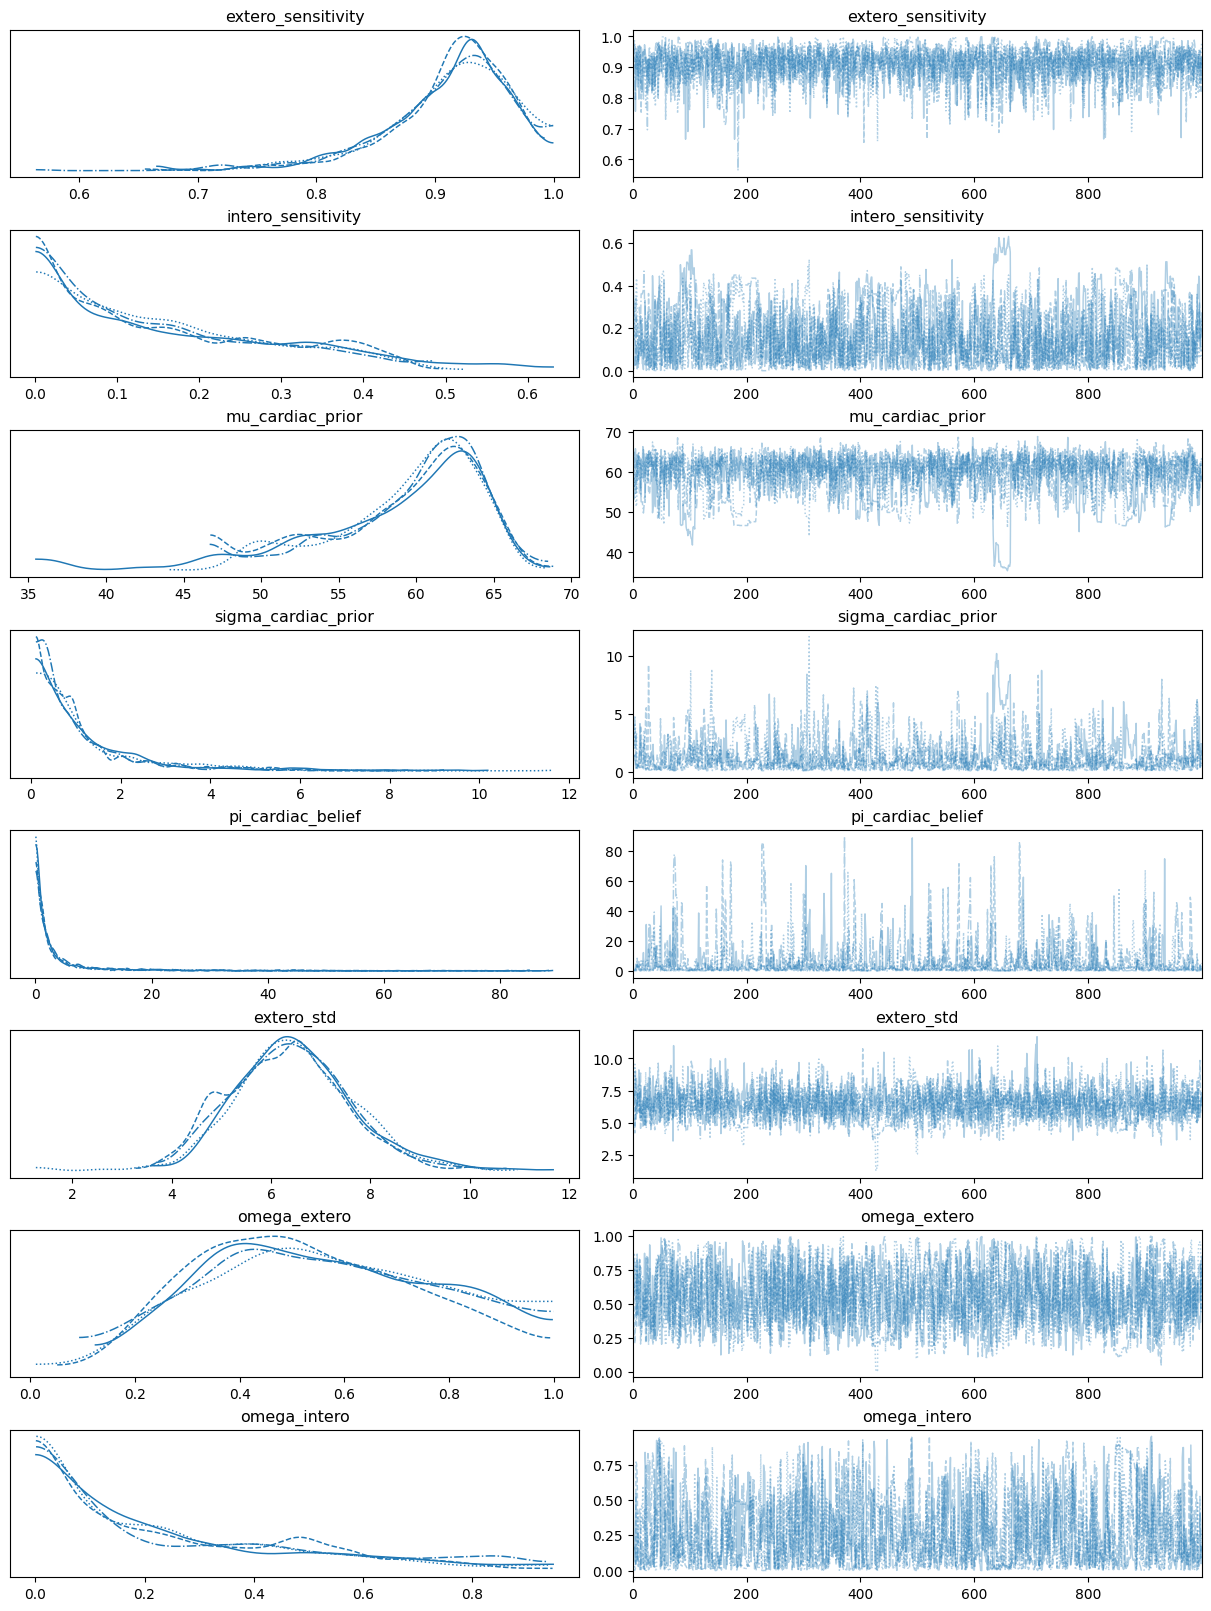

In [22]:
az.plot_trace(
    idata_weighted_update,
    var_names=[
        "extero_sensitivity",
        "intero_sensitivity",
        "mu_cardiac_prior",
        "sigma_cardiac_prior",
        "pi_cardiac_belief",
        "extero_std",
        "omega_extero",
        "omega_intero",
    ],
);

# Cardiac HGF

In [23]:
idata_cardiac_hgf, model_cardiac_hgf = sample_cardiac_hgf(
    input_data_extero=input_data_extero,
    input_data_intero=input_data_intero,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n_cores=4,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [interoceptive_precision, exteroceptive_precision, interoceptive_tonic_volatility, exteroceptive_tonic_volatility, exteroceptive_mean, interoceptive_mean]
/home/nicolas/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/nicolas/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.
There were 63 divergences after tuning. Increase `target_accept` or reparameterize.


In [24]:
pm.compute_log_likelihood(
    idata_cardiac_hgf, model=model_cardiac_hgf, var_names=["bin_intero"]
)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

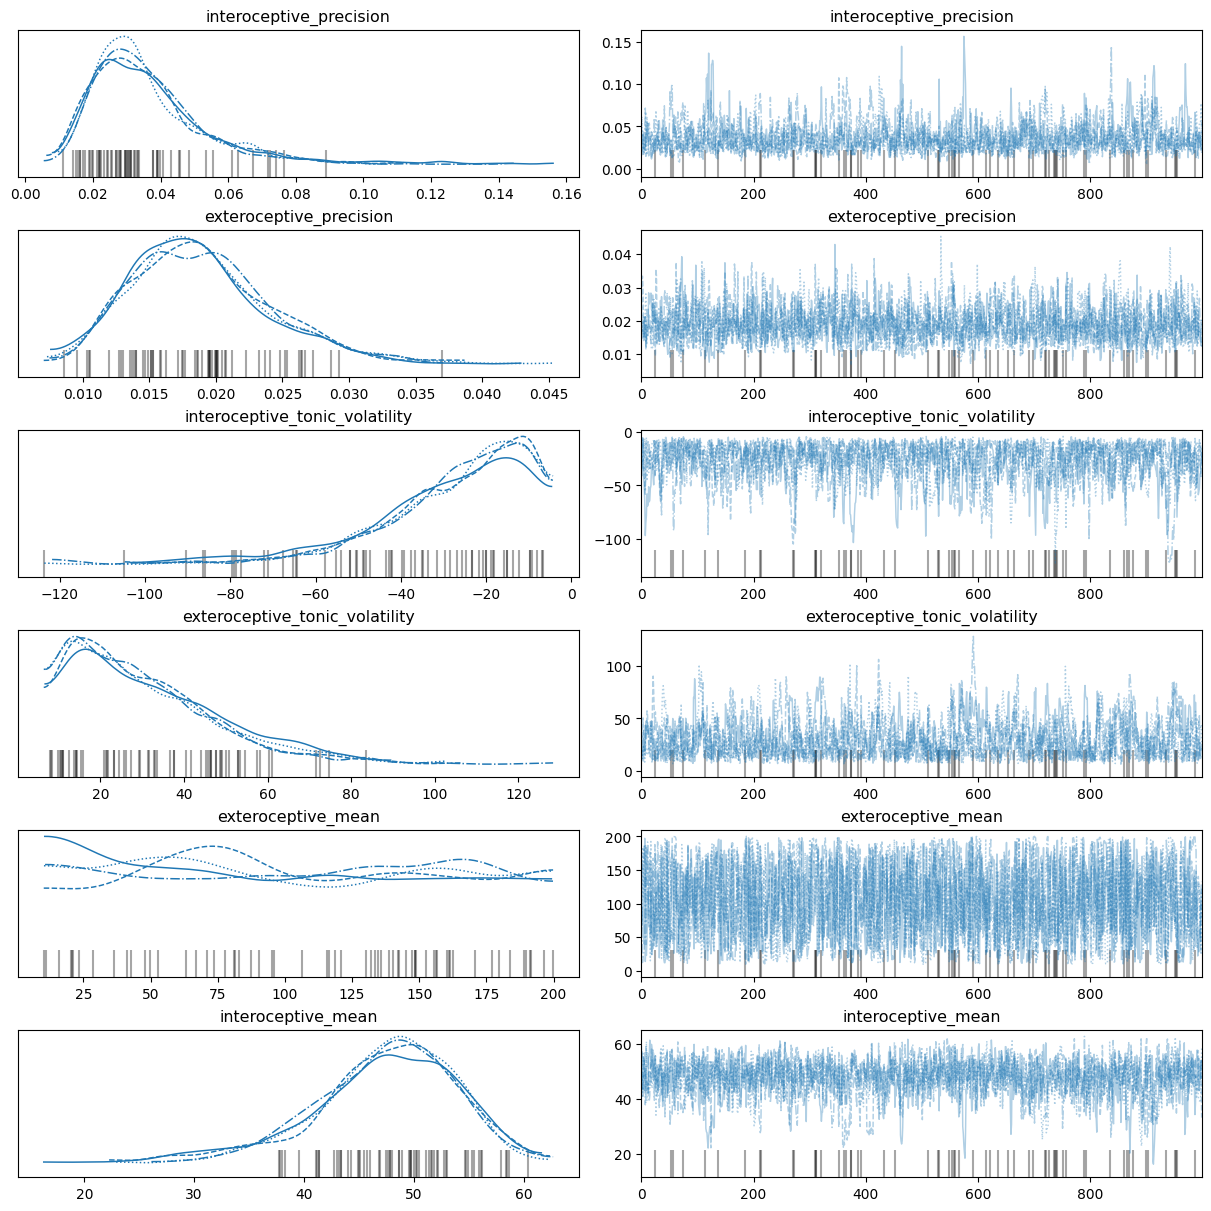

In [25]:
az.plot_trace(
    idata_cardiac_hgf,
    var_names=[
        "interoceptive_precision",
        "exteroceptive_precision",
        "interoceptive_tonic_volatility",
        "exteroceptive_tonic_volatility",
        "exteroceptive_mean",
        "interoceptive_mean",
    ],
);

# Model comparison

/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/

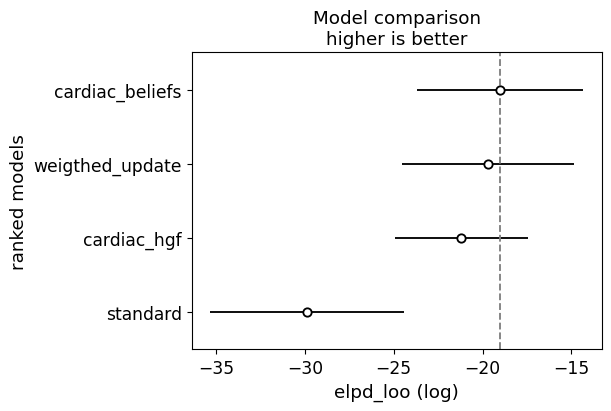

In [26]:
model_compare = az.compare(
    {
        "standard": idata_bayesian_psychophysics,
        "cardiac_beliefs": idata_cardiac_believing,
        "weigthed_update": idata_weighted_update,
        "cardiac_hgf": idata_cardiac_hgf,
    },
)
az.plot_compare(model_compare);